# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [11]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [3]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [5]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [6]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [7]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

In [8]:
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_label,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,False,False,True


# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

# LabelEncoder
Conveirte cada categoría en un número enter. Útil para la variable target o variables ordinales.
# OneHotEncoder
Crea una columna binaria por ada categoría. No implica ningún orden

### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

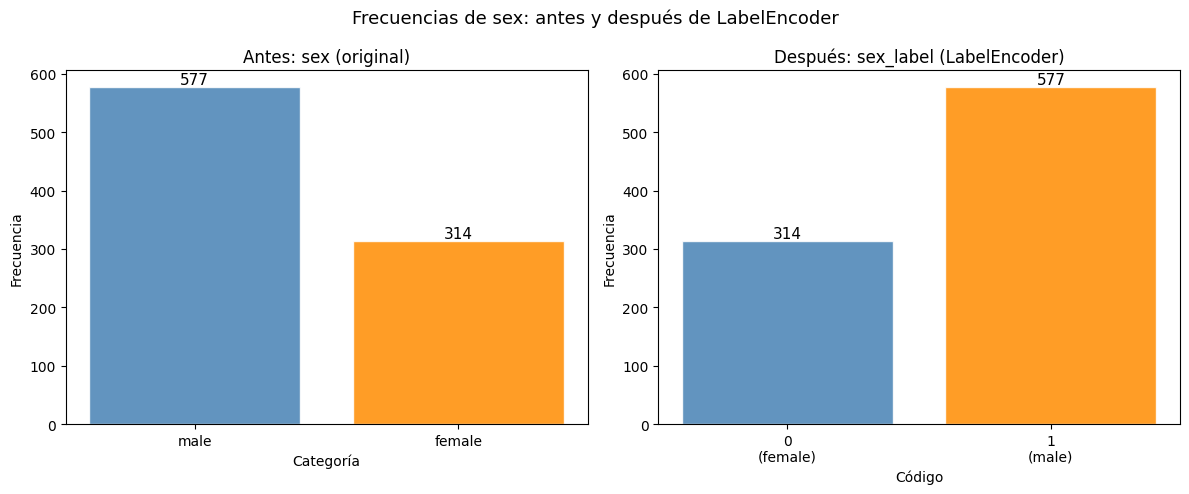

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Antes: valores originales (female / male) ---
sex_counts = data['sex'].value_counts()
axes[0].bar(sex_counts.index, sex_counts.values,
            color=['steelblue', 'darkorange'], edgecolor='white', alpha=0.85)
axes[0].set_title('Antes: sex (original)')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Frecuencia')
for i, v in enumerate(sex_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# --- Después: valores codificados (0 / 1) ---
sex_label_counts = data['sex_label'].value_counts().sort_index()
etiquetas = [f"{val}\n({label_encoder.classes_[val]})"
             for val in sex_label_counts.index]
axes[1].bar(etiquetas, sex_label_counts.values,
            color=['steelblue', 'darkorange'], edgecolor='white', alpha=0.85)
axes[1].set_title('Después: sex_label (LabelEncoder)')
axes[1].set_xlabel('Código')
axes[1].set_ylabel('Frecuencia')
for i, v in enumerate(sex_label_counts.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontsize=11)

plt.suptitle('Frecuencias de sex: antes y después de LabelEncoder', fontsize=13)
plt.tight_layout()
plt.show()

### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

In [14]:
onehot_encoder = pd.get_dummies(data['class'], prefix='class')
data = pd.concat([data, onehot_encoder], axis=1)
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,embark_town,alive,alone,sex_label,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,Southampton,no,False,1,False,False,True,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,Cherbourg,yes,False,0,True,False,False,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,Southampton,yes,True,0,False,False,True,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,Southampton,yes,False,0,False,False,True,True,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,Southampton,no,True,1,False,False,True,False,False,True


Muestra correctamente y de forma contundente que pasajeros tienen la primera clase y además facilita la lectura de los datos

### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

Eligiría one hot porque no es necesario enfocarse en todas y cada una de las diferentes clases, con usar tanto el máximo como el mínimo en las variables categóricas se puede obtener un promedio decente